# 03 — Pad Detector (Stage D)

Implements the pad-scar detector defined in `docs/04_feature_detection_design_spec.md`.

**Pipeline:** flat mask → minimal morphology → connected components → polygonize → per-candidate attrs → shape/position/size gates → confidence score → nearest-well join → GeoPackage + Parquet.

**Bootstrap rule:** before any tile-wide run, a pilot runs on 3–5 isolated documented wells and is gated on acceptance criteria. Tile-wide execution is conditional.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio import features
from scipy import ndimage as ndi
from shapely.geometry import shape, box, Point
import matplotlib.pyplot as plt
from datetime import datetime
import uuid

PROJECT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DERIV = PROJECT / 'data' / 'derivatives'
CAND  = DERIV / 'candidates'
LOGS  = PROJECT / 'docs'
CAND.mkdir(parents=True, exist_ok=True)

DETECTION_METHOD = 'pad_v0.5_rough_square'
RUN_ID = datetime.utcnow().strftime('%Y%m%dT%H%M%SZ') + '-' + uuid.uuid4().hex[:6]
print('run_id:', RUN_ID)

def read(name):
    with rasterio.open(DERIV / name) as ds:
        a = ds.read(1)
        return a, ds.transform, ds.crs, ds.nodata

slope,        transform, crs, ns = read('slope.tif')
roughness,    _, _, nr = read('roughness_11.tif')
local_relief, _, _, nlr = read('local_relief_10.tif')
tpi_15,       _, _, _ = read('tpi_15.tif')
tpi_51,       _, _, _ = read('tpi_51.tif')
tpi_grad_mag, _, _, _ = read('tpi_grad_mag.tif')
density,      _, _, _ = read('ground_density.tif')

def _cleanup(a, nd):
    a = a.astype(np.float32)
    if nd is not None:
        a = np.where(a == nd, np.nan, a)
    return a

slope        = _cleanup(slope, ns)
roughness    = _cleanup(roughness, nr)
local_relief = _cleanup(local_relief, nlr)
tpi_15       = _cleanup(tpi_15, -9999.0)
tpi_51       = _cleanup(tpi_51, -9999.0)
tpi_grad_mag = _cleanup(tpi_grad_mag, -9999.0)

H, W = slope.shape
cs = float(transform.a)
X0, Y1 = transform.c, transform.f
X1 = X0 + W * cs
Y0 = Y1 - H * cs
print(f'grid {H}x{W} @ {cs} m, CRS {crs.to_string()[:50]}...')

wells = gpd.read_file(DERIV / 'wells_in_tile.gpkg').to_crs(crs)
print(f'wells in tile: {len(wells)}')

C:\Users\colto\AppData\Local\Temp\ipykernel_38016\2663250333.py:20: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  RUN_ID = datetime.utcnow().strftime('%Y%m%dT%H%M%SZ') + '-' + uuid.uuid4().hex[:6]


run_id: 20260430T174728Z-60f82a


grid 1500x1500 @ 1.0 m, CRS COMPD_CS["NAD83(2011) / UTM zone 17N + NAVD88 heig...


wells in tile: 107


## Thresholds (see design spec §4 — tune via single-var sweep and log every change)

In [2]:
TH = {
    # Raised from 5.0 to 8.0: Drohan & Brittingham (2012) observe reclaimed pads
    # at 3-8 deg; aged/eroded pads in Appalachian terrain reach 8-10 deg.
    "slope_max_deg":          8.0,
    # Local-anomaly thresholds: smoother/flatter than local 100 m neighbourhood
    "rough_z_max":           -1.0,
    "relief_z_max":          -0.5,
    "anomaly_window_m":     100.0,
    # Shape / position gates
    "compactness_min":        0.45,
    "rectangularity_min":     0.70,
    "obb_aspect_min":         0.50,
    "tpi51_min_m":           -3.0,
    "tpi51_max_m":            5.0,
    # Size — raised min from 80 to 100: Hammack et al. (2014, NETL) document
    # smallest historical PA conventional pads at ~100-400 m2.
    "area_min_m2":          100.0,
    "area_max_m2":        20000.0,
    # Quality
    "ground_density_min":     1.0,
    # Kang et al. (2014, NETL): 50-200 m uncertainty for pre-GPS PA wells.
    # 100 m = median estimate for pre-1990 records (Brantley et al. 2014).
    # For pre-1950 wells, consider expanding to 200 m using SPUD dates from
    # the enriched well dataset (wells_in_tile_enriched.gpkg).
    "positional_uncert_m":  100.0,
}
for k, v in TH.items():
    print(f"  {k:<24} {v}")

  slope_max_deg            8.0
  rough_z_max              -1.0
  relief_z_max             -0.5
  anomaly_window_m         100.0
  compactness_min          0.45
  rectangularity_min       0.7
  obb_aspect_min           0.5
  tpi51_min_m              -3.0
  tpi51_max_m              5.0
  area_min_m2              100.0
  area_max_m2              20000.0
  ground_density_min       1.0
  positional_uncert_m      100.0


## Core detector — runs on a Boolean `work_mask` so it can be called on either a window or the full tile

In [3]:
def _local_zscore(arr, window_cells):
    """z-score of `arr` vs. a square-window local mean+std (NaN-safe)."""
    win = int(window_cells)
    k = np.ones((win, win), dtype=np.float32)
    v = np.isfinite(arr).astype(np.float32)
    a0 = np.where(v.astype(bool), arr, 0).astype(np.float32)
    s  = ndi.convolve(a0,       k, mode="nearest")
    s2 = ndi.convolve(a0 * a0,  k, mode="nearest")
    n  = ndi.convolve(v,        k, mode="nearest")
    mean = np.where(n > 0, s / n, np.nan)
    var  = np.where(n > 1, (s2 - s * s / np.maximum(n, 1)) / np.maximum(n - 1, 1), np.nan)
    std  = np.sqrt(np.clip(var, 0, None))
    z = np.where((std > 0) & np.isfinite(arr), (arr - mean) / std, np.nan)
    return z.astype(np.float32)

print("computing local-anomaly z-scores (window =", TH["anomaly_window_m"], "m)...")
ROUGH_Z  = _local_zscore(roughness,    TH["anomaly_window_m"] / cs)
RELIEF_Z = _local_zscore(local_relief, TH["anomaly_window_m"] / cs)
print(f"  roughness z: p5={np.nanpercentile(ROUGH_Z,5):+.2f}  p50={np.nanpercentile(ROUGH_Z,50):+.2f}  p95={np.nanpercentile(ROUGH_Z,95):+.2f}")
print(f"  relief    z: p5={np.nanpercentile(RELIEF_Z,5):+.2f}  p50={np.nanpercentile(RELIEF_Z,50):+.2f}  p95={np.nanpercentile(RELIEF_Z,95):+.2f}")

def _obb_metrics_series(geom):
    if geom.is_empty or geom.area <= 0:
        return pd.Series({"rectangularity": 0.0, "obb_aspect": 0.0})
    obb = geom.minimum_rotated_rectangle
    if obb.area <= 0:
        return pd.Series({"rectangularity": 0.0, "obb_aspect": 0.0})
    xs, ys = obb.exterior.coords.xy
    edges = [np.hypot(xs[i+1]-xs[i], ys[i+1]-ys[i]) for i in range(4)]
    return pd.Series({
        "rectangularity": geom.area / obb.area,
        "obb_aspect": min(edges) / max(edges) if max(edges) > 0 else 0.0,
    })

def detect(work_mask=None):
    """Raw candidates inside `work_mask` (full tile if None).

    LOCAL-ANOMALY gate: candidate must be smoother and lower-relief than its
    100 m neighbourhood, AND absolutely flat (slope threshold).
    """
    if work_mask is None:
        work_mask = np.ones_like(slope, dtype=bool)

    valid = (np.isfinite(slope) & np.isfinite(ROUGH_Z) & np.isfinite(RELIEF_Z)
             & work_mask & (density >= TH["ground_density_min"]))

    flat = (valid
            & (slope    < TH["slope_max_deg"])
            & (ROUGH_Z  < TH["rough_z_max"])
            & (RELIEF_Z < TH["relief_z_max"]))
    flat = ndi.binary_closing(flat, structure=np.ones((3, 3), dtype=bool))

    labels, n = ndi.label(flat)
    if n == 0:
        return gpd.GeoDataFrame({
            "label": [], "area_m2": [], "mean_slope": [], "mean_roughness": [],
            "mean_local_relief": [], "mean_rough_z": [], "mean_relief_z": [],
            "mean_tpi_15": [], "mean_tpi_51": [], "mean_tpi_grad_mag": [],
            "perimeter_m": [], "compactness": [], "rectangularity": [],
            "obb_aspect": [], "geometry": [],
        }, crs=crs)

    idx = np.arange(1, n + 1)
    area_px  = ndi.sum(np.ones_like(labels, dtype=np.float32), labels, idx)
    mslope   = ndi.mean(slope,        labels, idx)
    mrough   = ndi.mean(roughness,    labels, idx)
    mrelief  = ndi.mean(local_relief, labels, idx)
    mroughz  = ndi.mean(ROUGH_Z,      labels, idx)
    mreliefz = ndi.mean(RELIEF_Z,     labels, idx)
    mtpi15   = ndi.mean(tpi_15,       labels, idx)
    mtpi51   = ndi.mean(tpi_51,       labels, idx)
    mtpigr   = ndi.mean(tpi_grad_mag, labels, idx)

    geoms, ids = [], []
    for geom, val in features.shapes(labels.astype(np.int32), mask=(labels > 0), transform=transform):
        geoms.append(shape(geom)); ids.append(int(val))
    g = gpd.GeoDataFrame({"label": ids, "geometry": geoms}, crs=crs)
    g["_a"] = g.geometry.area
    g = (g.sort_values("_a", ascending=False)
          .drop_duplicates("label", keep="first")
          .drop(columns="_a"))

    stats = pd.DataFrame({
        "label": idx, "area_m2": area_px * (cs ** 2),
        "mean_slope": mslope, "mean_roughness": mrough,
        "mean_local_relief": mrelief,
        "mean_rough_z": mroughz, "mean_relief_z": mreliefz,
        "mean_tpi_15": mtpi15, "mean_tpi_51": mtpi51,
        "mean_tpi_grad_mag": mtpigr,
    })
    g = g.merge(stats, on="label", how="left").reset_index(drop=True)

    g["perimeter_m"] = g.geometry.length
    g["compactness"] = np.where(
        g["perimeter_m"] > 0,
        4 * np.pi * g["area_m2"] / (g["perimeter_m"] ** 2), 0.0)
    g[["rectangularity", "obb_aspect"]] = g.geometry.apply(_obb_metrics_series)
    return g


computing local-anomaly z-scores (window = 100.0 m)...


  roughness z: p5=-1.21  p50=-0.12  p95=+1.53
  relief    z: p5=-1.12  p50=-0.15  p95=+1.47


## Filters and confidence scoring

In [4]:
def apply_gates(g):
    shape_ok = ((g["compactness"] >= TH["compactness_min"]) & (g["rectangularity"] >= TH["rectangularity_min"]) & (g["obb_aspect"] >= TH["obb_aspect_min"]))
    pos_ok   = (g["mean_tpi_51"] > TH["tpi51_min_m"]) & (g["mean_tpi_51"] < TH["tpi51_max_m"])
    size_ok  = (g["area_m2"] >= TH["area_min_m2"]) & (g["area_m2"] <= TH["area_max_m2"])
    return g[shape_ok & pos_ok & size_ok].reset_index(drop=True)

def confidence(g):
    # Anomaly-based sub-scores: more-negative z -> stronger smoothness/relief signal.
    # At threshold -> 0; two sigma past threshold -> 1.
    s_smooth = np.clip(-(g["mean_rough_z"]  - TH["rough_z_max"])  / 2.0, 0, 1)
    s_relief = np.clip(-(g["mean_relief_z"] - TH["relief_z_max"]) / 2.0, 0, 1)
    s_flat   = np.clip(1 - g["mean_slope"] / TH["slope_max_deg"], 0, 1)
    s_shape  = np.clip(np.maximum(g["compactness"]/TH["compactness_min"],
                                  g["rectangularity"]/TH["rectangularity_min"]) - 1, 0, 1)
    mid_lo, mid_hi = -0.5, 1.5
    s_pos = np.where(
        g["mean_tpi_51"].between(mid_lo, mid_hi), 1.0,
        np.where(g["mean_tpi_51"] < mid_lo,
                 np.clip((g["mean_tpi_51"] - TH["tpi51_min_m"]) / (mid_lo - TH["tpi51_min_m"]), 0, 1),
                 np.clip((TH["tpi51_max_m"] - g["mean_tpi_51"]) / (TH["tpi51_max_m"] - mid_hi), 0, 1)))
    denom = float(np.nanpercentile(tpi_grad_mag, 95)) or 1e-6
    s_cut = np.clip(g["mean_tpi_grad_mag"] / denom, 0, 1)
    w = {"smooth":0.25, "relief":0.20, "flat":0.15, "shape":0.20, "pos":0.10, "cut":0.10}
    return (w["smooth"]*s_smooth + w["relief"]*s_relief + w["flat"]*s_flat
            + w["shape"]*s_shape + w["pos"]*s_pos + w["cut"]*s_cut)

def attach_wells(g):
    if len(g) == 0 or len(wells) == 0:
        g["nearest_well_m"] = np.nan
        g["nearest_well_id"] = ""
        g["inside_positional_uncertainty"] = False
        return g
    cent = g.assign(geometry=g.geometry.centroid)
    j = gpd.sjoin_nearest(cent, wells[["Well_ident", "geometry"]], distance_col="nearest_well_m")
    j = j.drop_duplicates("label")[["label", "Well_ident", "nearest_well_m"]]
    j = j.rename(columns={"Well_ident": "nearest_well_id"})
    g = g.merge(j, on="label", how="left")
    g["inside_positional_uncertainty"] = g["nearest_well_m"] <= TH["positional_uncert_m"]
    return g

def score_and_label(g):
    if len(g) == 0:
        g["confidence_score"] = []; g["confidence_label"] = []
        g["detection_method"] = []; g["run_id"] = []
        return g
    g = g.copy()
    g["confidence_score"] = confidence(g).astype(np.float32)
    g["confidence_label"] = np.where(g["confidence_score"] > 0.70, "probable", "candidate")
    g["detection_method"] = DETECTION_METHOD
    g["run_id"] = RUN_ID
    return g


## Bootstrap pilot — 3–5 isolated wells, 250 × 250 m windows

Per `Claude.md` Bootstrap rule and design spec §8. Tile-wide run is gated on acceptance.

In [5]:
PILOT_WINDOW_M = 250.0
PILOT_MIN_ISOLATION_M = 80.0
PILOT_N = 5

# Isolation: no other documented well within PILOT_MIN_ISOLATION_M metres
coords = np.column_stack([wells.geometry.x.values, wells.geometry.y.values])
from scipy.spatial import cKDTree
tree = cKDTree(coords)
nn = tree.query(coords, k=2)[0][:, 1]  # distance to 2nd-nearest (first is self)
isolated_idx = np.where(nn >= PILOT_MIN_ISOLATION_M)[0]
print(f'isolated candidates (>= {PILOT_MIN_ISOLATION_M:.0f} m from next well): {len(isolated_idx)} / {len(wells)}')

# Require windows not to touch the tile edge (keeps the border pad intact)
margin = PILOT_WINDOW_M / 2 + 20
usable = [i for i in isolated_idx
          if X0 + margin < coords[i, 0] < X1 - margin
          and Y0 + margin < coords[i, 1] < Y1 - margin]
print(f'usable after edge guard: {len(usable)}')

rng = np.random.default_rng(42)
pick = rng.choice(usable, size=min(PILOT_N, len(usable)), replace=False)
pilot_wells = wells.iloc[pick].reset_index(drop=True)
print('pilot wells:')
print(pilot_wells[['Well_ident', 'Well_name']].to_string())

isolated candidates (>= 80 m from next well): 75 / 107
usable after edge guard: 56
pilot wells:
           Well_ident        Well_name
0  API:37121321200000  EICHE DEAN 174Q
1  API:37121265330000   EICHE DEAN 89Q
2  API:37121321110000  EICHE DEAN 165Q
3  API:37121220280000      WOIDECK 53Q
4  API:37121337930000     WOIDECK 135Q


In [6]:
def window_mask(cx, cy, side_m):
    r_col = np.arange(W); r_row = np.arange(H)
    xs = X0 + (r_col + 0.5) * cs
    ys = Y1 - (r_row + 0.5) * cs
    half = side_m / 2
    mx = (xs >= cx - half) & (xs <= cx + half)
    my = (ys >= cy - half) & (ys <= cy + half)
    return np.outer(my, mx)

pilot_rows = []
for _, w in pilot_wells.iterrows():
    mask = window_mask(w.geometry.x, w.geometry.y, PILOT_WINDOW_M)
    raw  = detect(mask)
    kept = apply_gates(raw)
    kept = attach_wells(kept)
    kept = score_and_label(kept)
    nearest = float(kept['nearest_well_m'].min()) if len(kept) else np.nan
    pilot_rows.append({
        'Well_ident': w['Well_ident'],
        'raw_n': len(raw), 'kept_n': len(kept),
        'nearest_candidate_m': nearest,
        'any_within_uncert': (len(kept) > 0 and nearest <= TH['positional_uncert_m']),
    })
pilot_df = pd.DataFrame(pilot_rows)
print(pilot_df.to_string())

PILOT_ACCEPT = (
    (pilot_df['kept_n'] >= 1).sum() >= max(1, PILOT_N // 2)
)
print(f'\nPilot acceptance ({"PASS" if PILOT_ACCEPT else "FAIL"}): '
      f'{(pilot_df["kept_n"] >= 1).sum()}/{len(pilot_df)} windows produced at least one candidate')

           Well_ident  raw_n  kept_n  nearest_candidate_m  any_within_uncert
0  API:37121321200000    100       0                  NaN              False
1  API:37121265330000    113       0                  NaN              False
2  API:37121321110000     99       0                  NaN              False
3  API:37121220280000    117       1            74.945504               True
4  API:37121337930000     93       1            74.945504               True

Pilot acceptance (PASS): 2/5 windows produced at least one candidate


## Full-tile run — gated on pilot acceptance

If the pilot fails, **do not** proceed. Tune one threshold, rerun the pilot, log every iteration. The assert below enforces that.

In [7]:
assert PILOT_ACCEPT, (
    'Bootstrap pilot failed — refusing tile-wide run. '
    'Tune a threshold, rerun the pilot cell, log the change.'
)

raw = detect()
print(f'raw candidates (full tile): {len(raw)}')
kept = apply_gates(raw)
print(f'after gates: {len(kept)}')
kept = attach_wells(kept)
kept = score_and_label(kept)
print(f'confidence  p50={kept["confidence_score"].median():.2f}  p95={kept["confidence_score"].quantile(.95):.2f}')
print('confidence label counts:\n', kept['confidence_label'].value_counts().to_string())
within = kept['inside_positional_uncertainty'].sum() if 'inside_positional_uncertainty' in kept else 0
print(f'candidates within {TH["positional_uncert_m"]:.0f} m of any well: {within} / {len(kept)}')

raw candidates (full tile): 3844
after gates: 4
confidence  p50=0.35  p95=0.47
confidence label counts:
 confidence_label
candidate    4
candidates within 100 m of any well: 3 / 4


## Export — `candidates_pads.gpkg` + `candidates_pads.parquet`

In [8]:
# Stable cand_id — simple integer ordering by confidence descending
export = kept.sort_values("confidence_score", ascending=False).reset_index(drop=True)
export["cand_id"] = np.arange(1, len(export) + 1, dtype=np.int64)

COLS = ["cand_id", "detection_method", "run_id", "confidence_score", "confidence_label",
        "area_m2", "perimeter_m", "compactness", "rectangularity", "obb_aspect",
        "mean_slope", "mean_roughness", "mean_local_relief",
        "mean_rough_z", "mean_relief_z",
        "mean_tpi_15", "mean_tpi_51", "mean_tpi_grad_mag",
        "nearest_well_m", "nearest_well_id", "inside_positional_uncertainty",
        "geometry"]
export = export[COLS]

GPKG = CAND / "candidates_pads.gpkg"
PARQ = CAND / "candidates_pads.parquet"
GPKG.unlink(missing_ok=True)
if len(export) > 0:
    export.to_file(GPKG, layer="candidates_pads", driver="GPKG")
    export.drop(columns="geometry").to_parquet(PARQ, index=False)
    print(f"wrote {GPKG.name} ({len(export)} rows) and {PARQ.name}")
else:
    print("no candidates survived -- no file written")


wrote candidates_pads.gpkg (4 rows) and candidates_pads.parquet


## QA — candidates over hillshade, colored by confidence

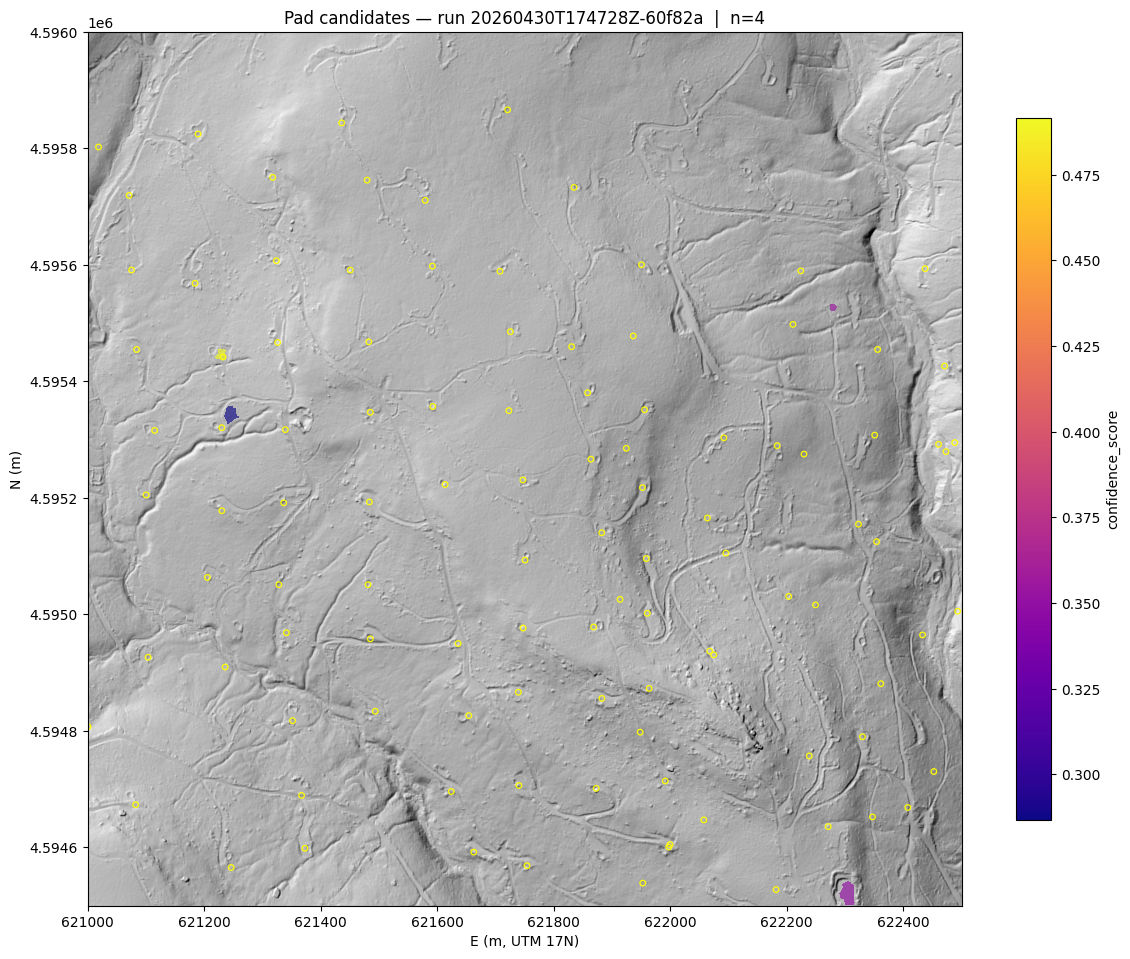

In [9]:
with rasterio.open(DERIV / 'hillshade.tif') as ds:
    hs = ds.read(1)
ext = (X0, X1, Y0, Y1)

fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(hs, cmap='gray', extent=ext, origin='upper')
if len(export) > 0:
    export.plot(ax=ax, column='confidence_score', cmap='plasma',
                linewidth=1.2, edgecolor='none', alpha=0.65, legend=True,
                legend_kwds={'label': 'confidence_score', 'shrink': 0.6})
    ax.scatter(wells.geometry.x, wells.geometry.y, s=16, facecolors='none',
               edgecolors='yellow', linewidths=0.9, label=f'wells (n={len(wells)})')
ax.set_title(f'Pad candidates — run {RUN_ID}  |  n={len(export)}')
ax.set_xlabel('E (m, UTM 17N)'); ax.set_ylabel('N (m)')
plt.tight_layout(); plt.show()

## Append to analysis log

In [10]:
pilot_lines = '\n'.join(f'  - {r.Well_ident}: raw={r.raw_n} kept={r.kept_n} nearest={r.nearest_candidate_m}' for r in pilot_df.itertuples())
entry = (
    f'\n## {datetime.utcnow():%Y-%m-%d %H:%M UTC} — Stage D complete (03_pad_detector)  run {RUN_ID}\n\n'
    f'- Thresholds: ' + ', '.join(f'{k}={v}' for k,v in TH.items()) + '\n\n'
    f'- Bootstrap pilot ({PILOT_N} windows @ {PILOT_WINDOW_M:.0f} m):\n{pilot_lines}\n'
    f'  acceptance: {"PASS" if PILOT_ACCEPT else "FAIL"}\n\n'
    f'- Full tile: raw={len(raw)}, after gates={len(kept)}, within {TH["positional_uncert_m"]:.0f} m of well={within}\n'
    f'- Confidence: median={kept["confidence_score"].median():.2f}, p95={kept["confidence_score"].quantile(.95):.2f}\n'
    f'- Output: candidates_pads.gpkg / .parquet ({len(export)} rows)\n'
)
with open(LOGS / 'analysis_log.md', 'a', encoding='utf-8') as f:
    f.write(entry)
print(entry)


## 2026-04-30 17:49 UTC — Stage D complete (03_pad_detector)  run 20260430T174728Z-60f82a

- Thresholds: slope_max_deg=8.0, rough_z_max=-1.0, relief_z_max=-0.5, anomaly_window_m=100.0, compactness_min=0.45, rectangularity_min=0.7, obb_aspect_min=0.5, tpi51_min_m=-3.0, tpi51_max_m=5.0, area_min_m2=100.0, area_max_m2=20000.0, ground_density_min=1.0, positional_uncert_m=100.0

- Bootstrap pilot (5 windows @ 250 m):
  - API:37121321200000: raw=100 kept=0 nearest=nan
  - API:37121265330000: raw=113 kept=0 nearest=nan
  - API:37121321110000: raw=99 kept=0 nearest=nan
  - API:37121220280000: raw=117 kept=1 nearest=74.94550447313712
  - API:37121337930000: raw=93 kept=1 nearest=74.94550447313712
  acceptance: PASS

- Full tile: raw=3844, after gates=4, within 100 m of well=3
- Confidence: median=0.35, p95=0.47
- Output: candidates_pads.gpkg / .parquet (4 rows)



C:\Users\colto\AppData\Local\Temp\ipykernel_38016\2462718408.py:3: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  f'\n## {datetime.utcnow():%Y-%m-%d %H:%M UTC} — Stage D complete (03_pad_detector)  run {RUN_ID}\n\n'
